# Import statements

In [1]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
import tqdm as notebook_tqdm
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
from tensorflow.keras.activations import gelu
from tensorflow.keras.regularizers import l2

In [3]:
print(np.__version__)

1.26.3


In [4]:
print(np.__file__)

/home/supadhyaya/.local/lib/python3.10/site-packages/numpy/__init__.py


In [5]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Load datasets

In [2]:
snp = pd.read_pickle("lasso_SNP_training_data.pkl")
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [3]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [4]:
snp1 = snp.iloc[:, 0:244]
snp1.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,2
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,2,2,0,0,2,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,2,0,0,0,2,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0


In [5]:
y1 = snp["seed_oil"]
y1.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [6]:
cov = snp.iloc[:,-34:]
cov.head()
## remove targte from this

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.6


In [7]:
cov = cov.drop(columns=['seed_oil'])

In [8]:
cov.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ESS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
y_final = snp["seed_oil"]
y_final.head()

Data-storage-ID
AB-01    17.6
AB-02    16.8
BR-24    20.6
ESS      20.9
ESS      19.6
Name: seed_oil, dtype: float64

In [10]:
pav = pd.read_pickle("gene_pav_afterFS_varthreshold_training_data.pkl")
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN076_SOYBEAN.CHEMICAL.NB.2009,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378_SOYBEAN.EVALUATION.MS2001_02,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470_SOYBEAN.EVALUATION.1IL66,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310_SOYBEAN.EVALUATION.2IL81.1,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [11]:
pav['Data-storage-ID'] = pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav = pav.reset_index(drop=True).set_index('Data-storage-ID')
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [12]:
pav1 = pav.iloc[:, 0:2918]
pav1.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,1,0,0,1,1
USB-378,1,0,1,1,1,1,1,1,1,0,...,1,0,0,0,1,1,1,0,0,1
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,1,0,0,1,0
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,1,1,0,0
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,1,1,0,0,1,0,0,0,0


In [13]:
y2 = pav["seed_oil"]
y2.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

In [14]:
pfam = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_training_data.pkl")
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN076_SOYBEAN.CHEMICAL.NB.2009,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378_SOYBEAN.EVALUATION.MS2001_02,0,0,1,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470_SOYBEAN.EVALUATION.1IL66,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310_SOYBEAN.EVALUATION.2IL81.1,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [15]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,0,0,1,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [16]:
pfam1 = pfam.iloc[:, 0:1196]
pfam1.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,0
USB-378,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
USB-470,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,1,1
SRR1533310,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,1,1,0,0


In [17]:
y3 = pfam["seed_oil"]
y3.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

In [18]:
X1 = snp1.values
X2 = pav1.values
X3 = pfam1.values
X4 = cov.values
y1 = y1.values
y2 = y2.values
y3 = y3.values
y_final = y_final.values

In [19]:
print(X1.shape, X2.shape, X3.shape, X4.shape)

(1144, 244) (1144, 2918) (1144, 1196) (1144, 33)


# Build model

In [20]:
#3 input model

num_features_1 = 244  # placeholder value
num_features_2 = 2918
num_features_3 = 1196 
# Input layers
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")

# Branch 1
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

# Branch 3
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# Concatenate all branches
merged = Concatenate()([x1, x2, x3])

# Final combined layers
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

#Build the model
model = Model(
    inputs=[input_1, input_2, input_3],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [111]:
# 4 - inout model
num_features_1 = 244  
num_features_2 = 2918
num_features_3 = 1196
num_features_4 = 33

# Input layers 
input_1 = Input(shape=(num_features_1,), name="input_1")
input_2 = Input(shape=(num_features_2,), name="input_2")
input_3 = Input(shape=(num_features_3,), name="input_3")
input_4 = Input(shape=(num_features_4,), name="input_4")

# Branch 1
x1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)
branch_out1 = Dense(1, activation='linear', name="branch_output_1")(x1)  # intermediate output

# Branch 2
x2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_2)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)
branch_out2 = Dense(1, activation='linear', name="branch_output_2")(x2)  # intermediate output

#Branch 3
x3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(input_3)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.3)(x3)
x3 = Dense(64, activation='relu')(x3)
branch_out3 = Dense(1, activation='linear', name="branch_output_3")(x3)  # intermediate output

# --- Concatenate all branches ---
merged = Concatenate()([x1, x2, x3, input_4])

# fused module
z = Dense(64, activation='relu')(merged)
z = BatchNormalization()(z)
z = Dropout(0.3)(z)
final_output = Dense(1, activation='linear', name="final_output")(z)

# model building
model = Model(
    inputs=[input_1, input_2, input_3, input_4],
    outputs=[branch_out1, branch_out2, branch_out3, final_output],
    name="multi_input_multi_output_model"
)

In [21]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 244)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2918)]               0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 1196)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  31360     ['input_1[0][0]']             
                                                                     

In [31]:

# --- Compile the model ---
model.compile(
    optimizer='adam',
    loss={
        "branch_output_1": "mse",
        "branch_output_2": "mse",
        "branch_output_3": "mse",
        "final_output": "mse"
    },
    metrics=['mae']
)

In [32]:
#check for differing dtypes
for i, X in enumerate([X1, X2, X3, X4], start=1):
    print(f"X{i} dtype:", getattr(X, "dtype", "no dtype"))
    print(f"X{i} sample:", X[:2])

for i, y in enumerate([y1, y2, y3, y_final], start=1):
    print(f"y{i} dtype:", getattr(y, "dtype", "no dtype"))
    print(f"y{i} sample:", y[:5])

X1 dtype: float32
X1 sample: [[0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0.
  0. 0. 2. 2. 0. 0. 0. 1. 2. 0. 2. 0. 0. 2. 2. 2. 0. 0. 0. 2. 2. 2. 0. 2.
  0. 2. 0. 0. 2. 0. 0. 0. 0. 2. 0. 0. 0. 2. 2. 2. 2. 2. 2. 0. 0. 2. 0. 0.
  0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 2. 2. 0. 0.
  0. 2. 0. 1. 2. 2. 2. 0. 0. 0. 0. 0. 2. 0. 0. 1. 0. 2. 1. 0. 0. 0. 2. 2.
  0. 0. 0. 0. 2. 0. 2. 2. 0. 0. 2. 2. 0. 2. 0. 0. 2. 0. 0. 0. 0. 2. 2. 0.
  2. 1. 0. 0. 0. 0. 2. 2. 0. 1. 2. 2. 0. 0. 2. 2. 2. 2. 2. 2. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 1. 0. 0. 1. 2. 0. 0. 0. 2. 2. 0. 2. 2. 2. 0. 2. 2. 0. 0.
  0. 0. 0. 1. 0. 0. 2. 0. 0. 2. 0. 0. 0. 2. 2. 2. 2. 0. 0. 1. 2. 2. 0. 2.
  0. 2. 0. 2. 1. 2. 2. 2. 2. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 2.]
 [2. 0. 0. 0. 2. 2. 2. 0. 0. 0. 0. 2. 0. 0. 0. 2. 2. 0. 0. 2. 2. 0. 0. 0.
  0. 0. 2. 2. 2. 0. 0. 1. 2. 0. 0. 2. 0. 0. 1. 2. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 2. 2. 0. 2. 2. 2. 2. 0. 0. 0. 2. 2. 0. 0. 0. 2. 0. 0. 0. 2. 

In [33]:
X1 = np.asarray(X1, dtype=np.float32)
X2 = np.asarray(X2, dtype=np.float32)
X3 = np.asarray(X3, dtype=np.float32)
X4 = np.asarray(X4, dtype=np.float32)

y1 = np.asarray(y1, dtype=np.float32)
y2 = np.asarray(y2, dtype=np.float32)
y3 = np.asarray(y3, dtype=np.float32)
y_final = np.asarray(y_final, dtype=np.float32)

In [34]:
# training all models

In [35]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',    # Stop based on validation loss
    patience=10,           # Wait 10 epochs for improvement
    restore_best_weights=True  # Restore weights from the best epoch
)

In [36]:
# Model checkpoint callback
checkpoint = ModelCheckpoint(
    "best_model_vt_withoutenv.h5",       # Filepath to save the model
    monitor='val_loss',    # Save based on validation loss
    save_best_only=True,   # Only save the best model
    save_weights_only=False  # Save the entire model (architecture + weights)
)

In [166]:
lr_reduction = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=20
    )

In [56]:
#history = model.fit( [X1, X2, X3], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.1, verbose=0,
                   callbacks=[early_stop, checkpoint, lr_reduction])

NameError: name 'lr_reduction' is not defined

In [37]:
history = model.fit( [X1, X2, X3], [y1, y2, y3, y_final], 
                     epochs=100, batch_size=32, validation_split=0.1, verbose=0,
                   callbacks=[early_stop, checkpoint])

/usr/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


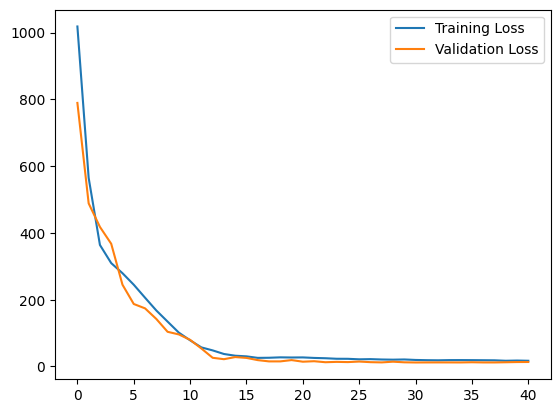

In [119]:
#for new model
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.savefig("loss_curve_so_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

In [52]:
model.save("first_model.h5")

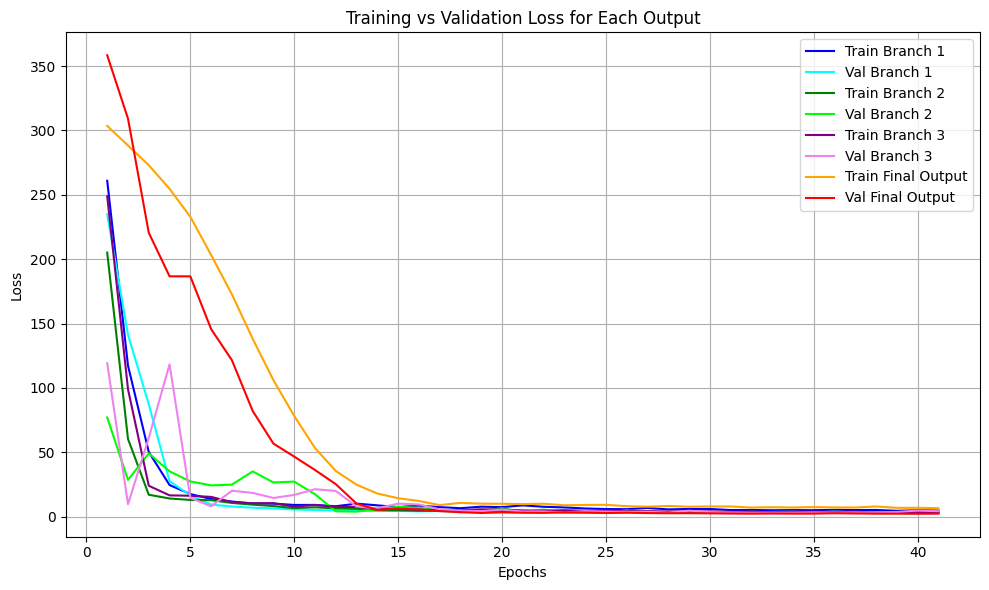

In [120]:

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(epochs, history.history['branch_output_1_loss'], label='Train Branch 1', color='blue')
plt.plot(epochs, history.history['val_branch_output_1_loss'], label='Val Branch 1', color='cyan')

# Branch 2
plt.plot(epochs, history.history['branch_output_2_loss'], label='Train Branch 2', color='green')
plt.plot(epochs, history.history['val_branch_output_2_loss'], label='Val Branch 2', color='lime')

# Branch 3
plt.plot(epochs, history.history['branch_output_3_loss'], label='Train Branch 3', color='purple')
plt.plot(epochs, history.history['val_branch_output_3_loss'], label='Val Branch 3', color='violet')

# Final Output
plt.plot(epochs, history.history['final_output_loss'], label='Train Final Output', color='orange')
plt.plot(epochs, history.history['val_final_output_loss'], label='Val Final Output', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Each Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("perbranch_curve_so_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

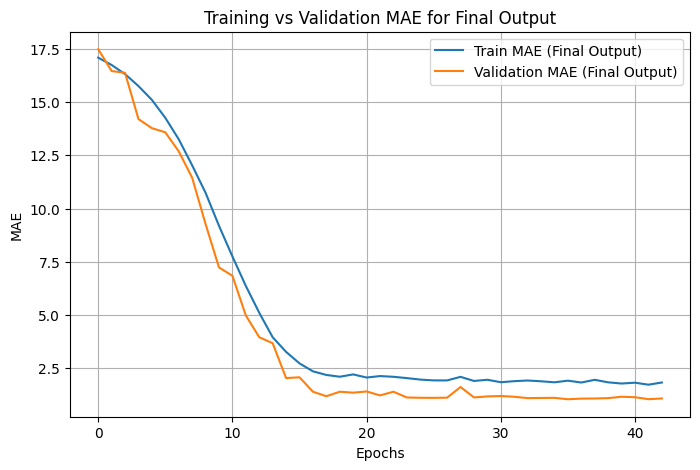

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['final_output_mae'], label='Train MAE (Final Output)')
plt.plot(history.history['val_final_output_mae'], label='Validation MAE (Final Output)')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Final Output')
plt.legend()
plt.grid(True)
plt.show()

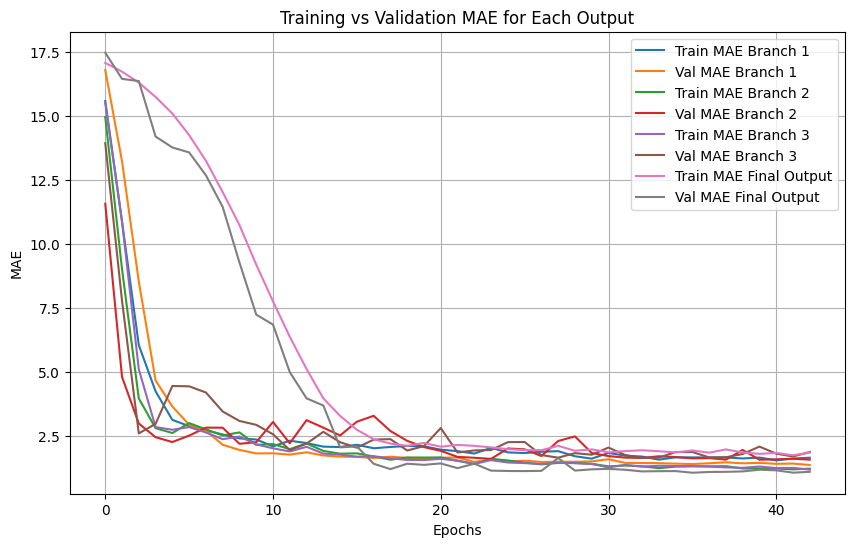

In [89]:
plt.figure(figsize=(10, 6))

# Branch 1
plt.plot(history.history['branch_output_1_mae'], label='Train MAE Branch 1')
plt.plot(history.history['val_branch_output_1_mae'], label='Val MAE Branch 1')

# Branch 2
plt.plot(history.history['branch_output_2_mae'], label='Train MAE Branch 2')
plt.plot(history.history['val_branch_output_2_mae'], label='Val MAE Branch 2')

# Branch 3
plt.plot(history.history['branch_output_3_mae'], label='Train MAE Branch 3')
plt.plot(history.history['val_branch_output_3_mae'], label='Val MAE Branch 3')

# Final Output
plt.plot(history.history['final_output_mae'], label='Train MAE Final Output')
plt.plot(history.history['val_final_output_mae'], label='Val MAE Final Output')

plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE for Each Output')
plt.legend()
plt.grid(True)
plt.show()

# Testing

In [121]:
holdout = pd.read_pickle("SNP_holdout_data.pkl")

In [122]:
holdout.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,HN009,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,HN010,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,HN015,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,HN017B,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,HN023,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,15.6


In [123]:
snp_holdout = holdout[snp1.columns]

In [124]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_2468766/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,2,2,0,0,2,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,2,2,0,2,2,2
HN015,2,0,0,0,2,2,2,0,2,2,...,0,2,0,0,2,2,0,2,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,2,0,0,0,2,2,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,2,2,0,0,0,2,0


In [125]:
snp_holdout.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,1,0,0,0,2,2,...,0,0,0,2,2,0,0,2,0,0
HN010,0,0,0,2,2,2,2,0,2,2,...,0,0,0,0,2,2,0,2,2,2
HN015,2,0,0,0,2,2,2,0,2,2,...,0,2,0,0,2,2,0,2,0,0
HN017B,0,0,0,2,2,2,2,0,2,2,...,2,0,0,0,2,2,0,0,0,0
HN023,2,0,0,0,2,0,2,0,2,2,...,0,0,0,2,2,0,0,0,2,0


In [126]:
holdout = pd.read_pickle("gene_pav_afterFS_varthreshold_holdout_data_pav.pkl")

In [127]:
pav_holdout = holdout[pav1.columns]

In [128]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_2468766/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,1,1,0,0,1
HN010,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1
HN015,1,0,1,1,1,1,1,1,0,1,...,1,0,0,1,1,1,0,0,1,1
HN017B,1,0,1,1,1,1,1,1,0,1,...,0,0,0,1,1,1,0,0,0,0
HN023,1,0,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,0,0,0,0


In [129]:
pav_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,1,1,0,0,1
HN010,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1
HN015,1,0,1,1,1,1,1,1,0,1,...,1,0,0,1,1,1,0,0,1,1
HN017B,1,0,1,1,1,1,1,1,0,1,...,0,0,0,1,1,1,0,0,0,0
HN023,1,0,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,0,0,0,0


In [130]:
holdout = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_holdout_data_pav.pkl")

In [131]:
pfam_holdout = holdout[pfam1.columns]

In [132]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_2468766/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,1,0
HN010,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,0,1,0,0,0
HN015,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
HN017B,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,0
HN023,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0


In [133]:
pfam_holdout.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,1,0
HN010,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,0,1,0,0,0
HN015,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
HN017B,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,1,0,0,0
HN023,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0


In [134]:
cov_holdout = holdout[cov.columns]

In [135]:
cov_holdout.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [136]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_2468766/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [137]:
y1_test = holdout['seed_oil'].values
y2_test = holdout['seed_oil'].values
y3_test = holdout['seed_oil'].values
y_final_test = holdout['seed_oil'].values

In [138]:
y1_test

array([16.8, 18.3, 15. , 15.5, 15.6, 18.1,  6.5, 14.3, 11.7,  9.9, 17.3,
       19.8, 16.2, 16.5, 16.5, 20.3, 18.7, 17.8, 17.2, 18.9, 20.5, 11. ,
       11.5, 14.9, 17.3,  9. , 18.9, 20.1,  8.8, 11.7, 10.7, 12.1, 11.8,
       11.4,  9.6, 11.7, 10.9, 11.1, 10.6, 11.3,  9.6, 10.6, 10.9,  7.2,
       20.9, 19.1, 19.4, 21.7, 21.4, 21.7, 22.4, 18.9, 18.3,  6.8, 17.2,
       19.1, 17.8, 21. , 20.4, 19. , 20.6, 20.2, 19. , 21.6, 18.4, 12.7,
       14.7, 18.5, 15.9, 20.8, 17.6, 19.4, 17.9, 20.5, 20.3, 18.4, 15.7,
       15. , 17.5, 20.8, 21.2, 18.3, 20.9, 18.5, 19.6, 18.5, 17.3, 16.7,
       16.2, 17.8, 19.6, 15.7, 20.4, 18. , 18.1, 15.9, 15.8, 19.9, 19.5,
       20. , 20.3, 16.8, 20. , 19.2, 18.9, 21.6, 18.2, 16. , 12.6, 20.8,
       18. , 19.5, 20.7, 20. , 19.8, 19.3, 17.9, 17.2, 17.1, 17.9, 18.9,
       20.7, 18. , 15.1, 17.7, 18.7, 14.8, 16.2])

In [139]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [39]:
model = load_model('best_models/best_model_vt_withoutenv.h5')

In [140]:
model.summary()

Model: "multi_input_multi_output_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 244)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 2918)]               0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 1196)]               0         []                            
                                                                                                  
 dense_14 (Dense)            (None, 128)                  31360     ['input_1[0][0]']             
                                                                     

In [141]:
print(X1_test.dtype, X2_test.dtype, X3_test.dtype, X4_test.dtype)

int64 object int64 int64


In [142]:
X1_test = X1_test.astype("float32")
X2_test = X2_test.astype("float32")
X3_test = X3_test.astype("float32")
X4_test = X4_test.astype("float32")

In [143]:
print(X1_test.shape)
print(X2_test.shape)
print(X3_test.shape)
print(X4_test.shape)

(128, 244)
(128, 2918)
(128, 1196)
(128, 33)


In [144]:
pred1, pred2, pred3, pred_final = model.predict(
    [X1_test, X2_test, X3_test, X4_test]
)

4/4 [==============================] - 0s 2ms/step


In [145]:
results = model.evaluate(
    [X1_test, X2_test, X3_test, X4_test],
    [y1_test, y2_test, y3_test, y_final_test],
    verbose=1
)

print(results)

4/4 [==============================] - 0s 4ms/step - loss: 13.0358 - branch_output_1_loss: 3.5158 - branch_output_2_loss: 3.3070 - branch_output_3_loss: 3.8658 - final_output_loss: 2.3399 - branch_output_1_mae: 1.4067 - branch_output_2_mae: 1.4260 - branch_output_3_mae: 1.5329 - final_output_mae: 1.1855
[13.035772323608398, 3.5158073902130127, 3.3069937229156494, 3.8658430576324463, 2.3399393558502197, 1.4067320823669434, 1.425979733467102, 1.5328619480133057, 1.1854501962661743]


In [146]:
# rmse
rmse_1 = np.sqrt(mean_squared_error(y1_test, pred1))
rmse_2 = np.sqrt(mean_squared_error(y2_test, pred2))
rmse_3 = np.sqrt(mean_squared_error(y3_test, pred3))
rmse_final = np.sqrt(mean_squared_error(y_final_test, pred_final))

# r2
r2_1 = r2_score(y1_test, pred1)
r2_2 = r2_score(y2_test, pred2)
r2_3 = r2_score(y3_test, pred3)
r2_final = r2_score(y_final_test, pred_final)

# r
pearson_1, pval_1 = pearsonr(y1_test.flatten(), pred1.flatten())
pearson_2, pval_2 = pearsonr(y2_test.flatten(), pred2.flatten())
pearson_3, pval_3 = pearsonr(y3_test.flatten(), pred3.flatten())
pearson_final, pval_final = pearsonr(y_final_test.flatten(), pred_final.flatten())


print("\n===== PERFORMANCE METRICS =====")
print(f"Branch 1 – RMSE: {rmse_1:.4f}, R²: {r2_1:.4f}, Pearson r: {pearson_1:.4f} (p={pval_1:.2e})")
print(f"Branch 2 – RMSE: {rmse_2:.4f}, R²: {r2_2:.4f}, Pearson r: {pearson_2:.4f} (p={pval_2:.2e})")
print(f"Branch 3 – RMSE: {rmse_3:.4f}, R²: {r2_3:.4f}, Pearson r: {pearson_3:.4f} (p={pval_3:.2e})")
print(f"Final Output – RMSE: {rmse_final:.4f}, R²: {r2_final:.4f}, Pearson r: {pearson_final:.4f} (p={pval_final:.2e})")


===== PERFORMANCE METRICS =====
Branch 1 – RMSE: 1.8750, R²: 0.7404, Pearson r: 0.8691 (p=2.47e-40)
Branch 2 – RMSE: 1.8185, R²: 0.7559, Pearson r: 0.8783 (p=3.29e-42)
Branch 3 – RMSE: 1.9662, R²: 0.7146, Pearson r: 0.8624 (p=4.57e-39)
Final Output – RMSE: 1.5297, R²: 0.8273, Pearson r: 0.9139 (p=3.53e-51)


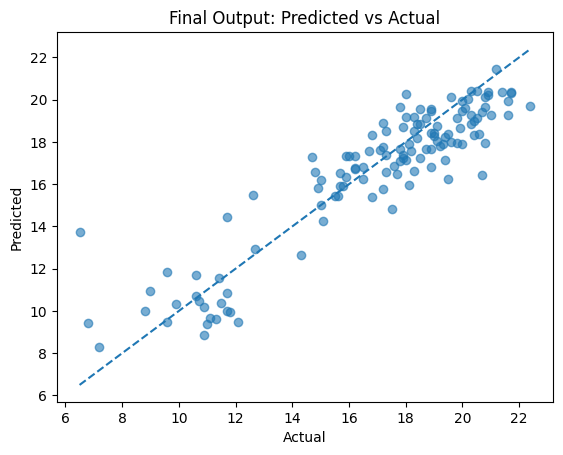

In [147]:
plt.scatter(y_final_test, pred_final, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Final Output: Predicted vs Actual")
plt.plot([y_final_test.min(), y_final_test.max()],
         [y_final_test.min(), y_final_test.max()],
         linestyle="--")   # 1:1 line
plt.savefig("predicted_actual_so_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()

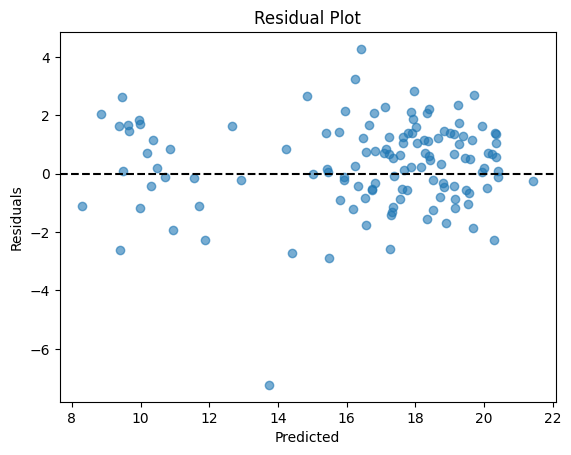

In [148]:
residuals = y_final_test - pred_final.reshape(-1)

plt.scatter(pred_final, residuals, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_so_vt_withenv.png", dpi=600, bbox_inches="tight")
plt.show()